## ☄️ Análisis de Datos y Modelo Predictivo de Riesgo de Asteroides

### 📖 Descripción del proyecto

En esta notebook se desarrolla un análisis exploratorio de datos (EDA) y la construcción de modelos predictivos utilizando el dataset NASA Near-Earth Objects (NEOs).

El conjunto de datos reúne información sobre asteroides cercanos a la Tierra, incluyendo características físicas y orbitales como el diámetro estimado, la magnitud absoluta, la velocidad relativa, la distancia mínima de aproximación y el cuerpo celeste alrededor del cual orbitan.

El objetivo del proyecto es comprender las características de estos objetos, explorar las relaciones entre las variables y desarrollar un modelo capaz de predecir si un asteroide puede ser clasificado como potencialmente peligroso (`is_hazardous`)

In [49]:
# Librerias 
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
import scipy.stats
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score, accuracy_score,confusion_matrix,classification_report
from sklearn.metrics import precision_score, recall_score, f1_score, silhouette_score, roc_auc_score
from math import sqrt
import os
from os import listdir
from datetime import datetime
import pandas as pd
from matplotlib.dates import DateFormatter
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split,cross_val_score
import seaborn as sns
import plotly.express as px
import kagglehub
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

#Libreiras de pipeline
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
# Selección de variables
from sklearn.feature_selection import SelectKBest, f_classif
#Validaciones cruzadas
from sklearn.model_selection import cross_val_score, GridSearchCV
import os
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
print ("librerias ok")

librerias ok


In [2]:
# Directorio actual
print(os.getcwd())

d:\Josefina\Proyectos\Datascience\Curso_ML\Modelos_ML\asteroides


In [7]:
df = pd.read_csv("../data/asteroides.csv")

df.head()

,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),...,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion,Equinox,Hazardous
0,3703080,3703080,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551,J2000,True
1,3723955,3723955,21.3,0.146068,0.326618,146.067964,326.617897,0.090762,0.202951,479.225620,...,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330,J2000,False
2,2446862,2446862,20.3,0.231502,0.517654,231.502122,517.654482,0.143849,0.321655,759.521423,...,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371,J2000,True
3,3092506,3092506,27.4,0.008801,0.019681,8.801465,19.680675,0.005469,0.012229,28.876199,...,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277,J2000,False
4,3514799,3514799,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395,J2000,True


In [ ]:
#Que columnas tiene, son 40 en total
df.columns

Index(['Neo Reference ID', 'Name', 'Absolute Magnitude', 'Est Dia in KM(min)',
       'Est Dia in KM(max)', 'Est Dia in M(min)', 'Est Dia in M(max)',
       'Est Dia in Miles(min)', 'Est Dia in Miles(max)',
       'Est Dia in Feet(min)', 'Est Dia in Feet(max)', 'Close Approach Date',
       'Epoch Date Close Approach', 'Relative Velocity km per sec',
       'Relative Velocity km per hr', 'Miles per hour',
       'Miss Dist.(Astronomical)', 'Miss Dist.(lunar)',
       'Miss Dist.(kilometers)', 'Miss Dist.(miles)', 'Orbiting Body',
       'Orbit ID', 'Orbit Determination Date', 'Orbit Uncertainity',
       'Minimum Orbit Intersection', 'Jupiter Tisserand Invariant',
       'Epoch Osculation', 'Eccentricity', 'Semi Major Axis', 'Inclination',
       'Asc Node Longitude', 'Orbital Period', 'Perihelion Distance',
       'Perihelion Arg', 'Aphelion Dist', 'Perihelion Time', 'Mean Anomaly',
       'Mean Motion', 'Equinox', 'Hazardous'],
      dtype='str')

In [ ]:
#Vemos las catracteristicas generales de las variables
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4687 entries, 0 to 4686
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Neo Reference ID              4687 non-null   int64  
 1   Name                          4687 non-null   int64  
 2   Absolute Magnitude            4687 non-null   float64
 3   Est Dia in KM(min)            4687 non-null   float64
 4   Est Dia in KM(max)            4687 non-null   float64
 5   Est Dia in M(min)             4687 non-null   float64
 6   Est Dia in M(max)             4687 non-null   float64
 7   Est Dia in Miles(min)         4687 non-null   float64
 8   Est Dia in Miles(max)         4687 non-null   float64
 9   Est Dia in Feet(min)          4687 non-null   float64
 10  Est Dia in Feet(max)          4687 non-null   float64
 11  Close Approach Date           4687 non-null   str    
 12  Epoch Date Close Approach     4687 non-null   int64  
 13  Relative Veloc

In [13]:
#Analisis descriptivos
df.describe()

,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),...,Semi Major Axis,Inclination,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion
count,4.687000e+03,4.687000e+03,4687.000000,4687.000000,4687.000000,4687.000000,4687.000000,4687.000000,4687.000000,4687.000000,...,4687.000000,4687.000000,4687.000000,4687.000000,4687.000000,4687.000000,4687.000000,4.687000e+03,4687.000000,4687.000000
mean,3.272298e+06,3.272298e+06,22.267865,0.204604,0.457509,204.604203,457.508906,0.127135,0.284283,671.273653,...,1.400264,13.373844,172.157275,635.582076,0.813383,183.932151,1.987144,2.457728e+06,181.167927,0.738242
std,5.486011e+05,5.486011e+05,2.890972,0.369573,0.826391,369.573402,826.391249,0.229642,0.513496,1212.511199,...,0.524154,10.936227,103.276777,370.954727,0.242059,103.513035,0.951519,9.442264e+02,107.501623,0.342627
min,2.000433e+06,2.000433e+06,11.160000,0.001011,0.002260,1.010543,2.259644,0.000628,0.001404,3.315431,...,0.615920,0.014513,0.001941,176.557161,0.080744,0.006918,0.803765,2.450100e+06,0.003191,0.086285
25%,3.097594e+06,3.097594e+06,20.100000,0.033462,0.074824,33.462237,74.823838,0.020792,0.046493,109.784247,...,1.000635,4.962341,83.081208,365.605031,0.630834,95.625916,1.266059,2.457815e+06,87.006918,0.453289
50%,3.514799e+06,3.514799e+06,21.900000,0.110804,0.247765,110.803882,247.765013,0.068850,0.153954,363.529809,...,1.240981,10.311836,172.625393,504.947292,0.833153,189.761641,1.618195,2.457973e+06,185.718889,0.712946
75%,3.690060e+06,3.690060e+06,24.500000,0.253837,0.567597,253.837029,567.596853,0.157727,0.352688,832.798679,...,1.678364,19.511681,255.026909,794.195972,0.997227,271.777557,2.451171,2.458108e+06,276.531946,0.984669
max,3.781897e+06,3.781897e+06,32.100000,15.579552,34.836938,15579.552413,34836.938254,9.680682,21.646663,51114.018738,...,5.072008,75.406667,359.905890,4172.231343,1.299832,359.993098,8.983852,2.458839e+06,359.917991,2.039000


In [ ]:
# Por conocimiento previo nos quedamos con algunas de las variables de interes
columnas_utiles = [
    'Absolute Magnitude',          # Brillo del asteroide (suele indicar el tamaño)
    'Est Dia in KM(max)',          # Diámetro máximo estimado en kilómetros
    'Relative Velocity km per hr', # A qué velocidad viaja
    'Miss Dist.(Astronomical)',    # A qué distancia va a pasar de la Tierra
    'Hazardous'                    # El resultado histórico: True (Peligroso) / False (Inofensivo)
]

#Hacemos una copia para trabajar con este dataset
df_asteroides = df[columnas_utiles].copy()


In [ ]:
#Corroboramos si hay nulos
df_asteroides.isnull().sum() #No hay esta limpio

Absolute Magnitude             0
Est Dia in KM(max)             0
Relative Velocity km per hr    0
Miss Dist.(Astronomical)       0
Hazardous                      0
dtype: int64

In [ ]:
#Corroboramos el tipo de dato de cada variable
df_asteroides.dtypes

Absolute Magnitude             float64
Est Dia in KM(max)             float64
Relative Velocity km per hr    float64
Miss Dist.(Astronomical)       float64
Hazardous                         bool
dtype: object

Solo la variable objetivo es bool, la deberiamos tranformar en datos numerico 0-1

In [23]:
#Por las dudas corroboramos que sea T/F
df_asteroides['Hazardous'].unique()

array([ True, False])

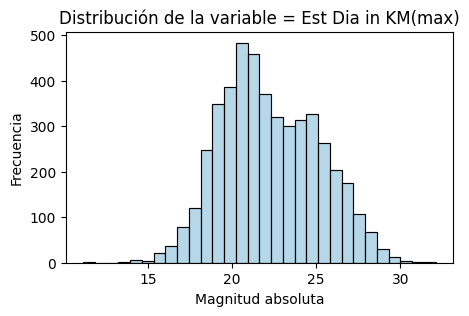

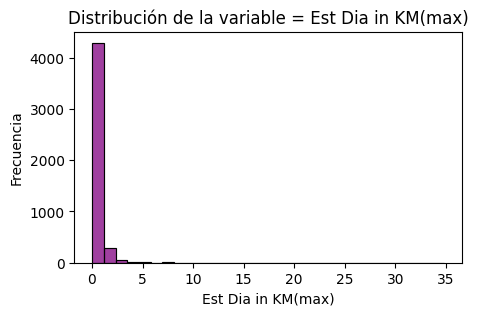

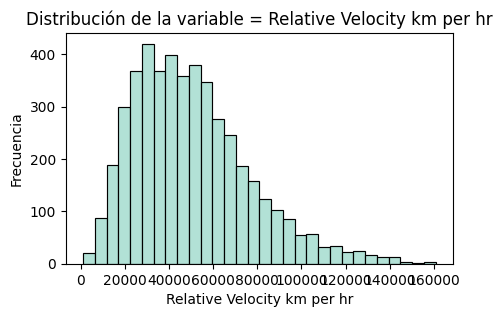

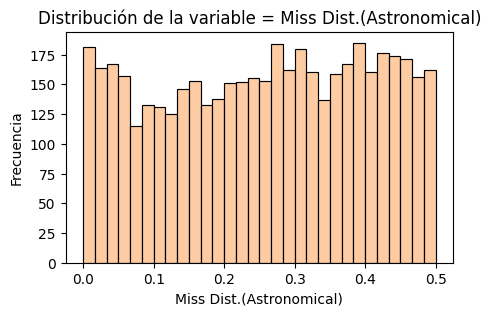

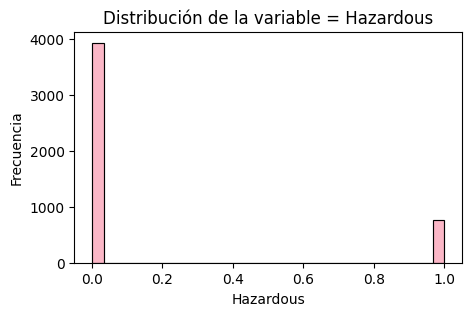

In [ ]:
# Hacemos un plot para ver la distribucion de las variables
# Absolute Magnitude
plt.figure(figsize=(5, 3))
sns.histplot(data=df_asteroides, x="Absolute Magnitude", bins=30, color ="#9ecae1")
plt.xlabel("Magnitud absoluta")
plt.ylabel("Frecuencia")
plt.title("Distribución de la variable = Est Dia in KM(max)")
plt.show()


# --------------------------------------------------------------------- #
# Est Dia in KM(max)
 
plt.figure(figsize=(5, 3))
sns.histplot(data=df_asteroides, x="Est Dia in KM(max)", bins=30, color="purple") 
plt.xlabel("Est Dia in KM(max)")
plt.ylabel("Frecuencia")
plt.title("Distribución de la variable = Est Dia in KM(max)")
plt.show()
 
# --------------------------------------------------------------------- #          
# Relative Velocity km per hr

plt.figure(figsize=(5, 3))
sns.histplot(data=df_asteroides, x="Relative Velocity km per hr", bins=30, color="#99d8c9")
plt.xlabel("Relative Velocity km per hr")
plt.ylabel("Frecuencia")
plt.title("Distribución de la variable = Relative Velocity km per hr")
plt.show()

# --------------------------------------------------------------------- #
# Miss Dist.(Astronomical)  
plt.figure(figsize=(5, 3))
sns.histplot(data=df_asteroides, x="Miss Dist.(Astronomical)", bins=30, color = "#fdbb84")
plt.xlabel("Miss Dist.(Astronomical)")
plt.ylabel("Frecuencia")
plt.title("Distribución de la variable = Miss Dist.(Astronomical)")
plt.show()



# --------------------------------------------------------------------- #
# Hazardous 
plt.figure(figsize=(5, 3))
sns.histplot(data=df_asteroides, x="Hazardous", bins=30, color ="#fa9fb5")
plt.xlabel("Hazardous")
plt.ylabel("Frecuencia")
plt.title("Distribución de la variable = Hazardous")
plt.show()                      

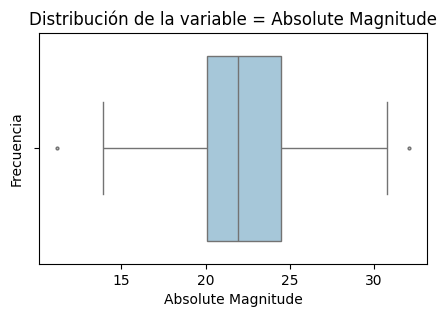

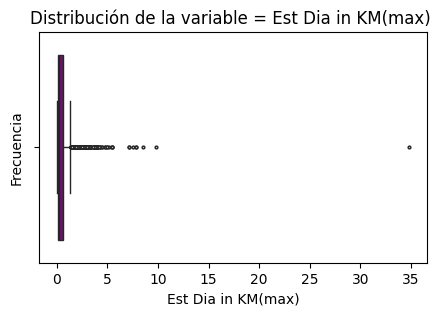

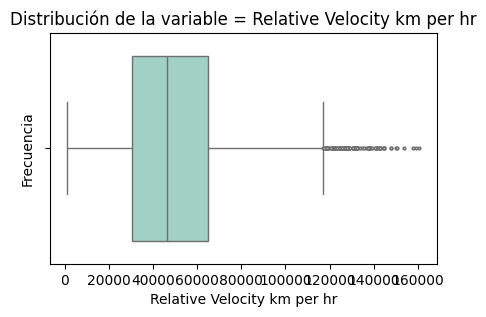

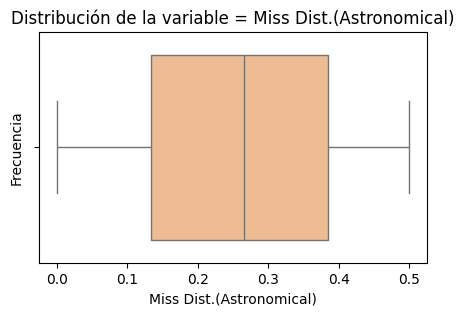

In [ ]:
#Boxplots de todas las variables
# --------------------------------------------------------------------- #
# Absolute Magnitude
plt.figure(figsize=(5, 3))
sns.boxplot(data=df_asteroides, x="Absolute Magnitude", color =  "#9ecae1", 
            flierprops={
        "marker": "o",
        "markerfacecolor": "#bdbdbd",
        # "markeredgecolor": "black",
        "markersize": 2
    })

plt.xlabel("Absolute Magnitude")
plt.ylabel("Frecuencia")
plt.title("Distribución de la variable = Absolute Magnitude")
plt.show()




# --------------------------------------------------------------------- #
# Est Dia in KM(max)  
plt.figure(figsize=(5, 3))
sns.boxplot(data=df_asteroides, x="Est Dia in KM(max)", color ="purple", 
        flierprops={
        "marker": "o",
        "markerfacecolor": "#bdbdbd",
        # "markeredgecolor": "black",
        "markersize": 2
    })

plt.xlabel("Est Dia in KM(max)")
plt.ylabel("Frecuencia")
plt.title("Distribución de la variable = Est Dia in KM(max) ")
plt.show()


# --------------------------------------------------------------------- #
# Relative Velocity km per hr
plt.figure(figsize=(5, 3))
sns.boxplot(data=df_asteroides, x="Relative Velocity km per hr", color = "#99d8c9",
            flierprops={
        "marker": "o",
        "markerfacecolor": "#bdbdbd",
        #"markeredgecolor": "black",
        "markersize": 2
    })

plt.xlabel("Relative Velocity km per hr")
plt.ylabel("Frecuencia")
plt.title("Distribución de la variable = Relative Velocity km per hr")
plt.show()


# --------------------------------------------------------------------- #
# Miss Dist.(Astronomical) 
plt.figure(figsize=(5, 3))
sns.boxplot(data=df_asteroides, x="Miss Dist.(Astronomical)", color = "#fdbb84",
            flierprops={
        "marker": "o",
        "markerfacecolor": "#bdbdbd",
        #"markeredgecolor": "black",
        "markersize": 2
    })

plt.xlabel("Miss Dist.(Astronomical)")
plt.ylabel("Frecuencia")
plt.title("Distribución de la variable = Miss Dist.(Astronomical)")
plt.show()




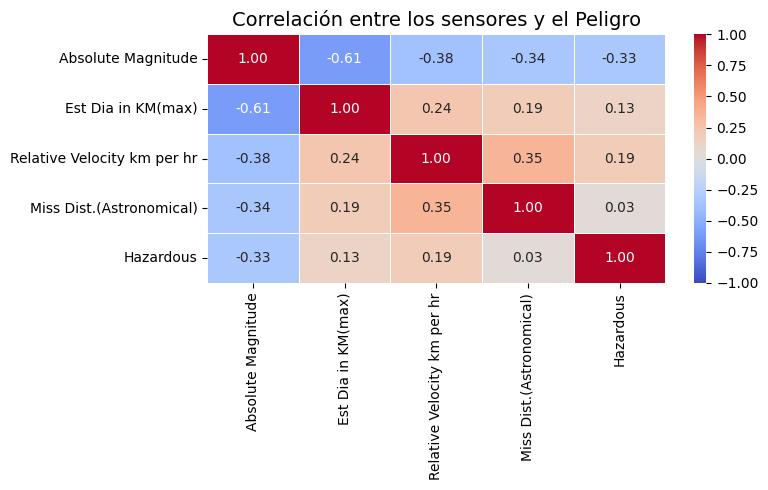

In [40]:
#Matriz de correlacion entre todas las variables para evitar que se duplique la informacion

plt.figure(figsize=(8,5))

corr_matrix = df_asteroides.corr(numeric_only=True)

# sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white", 
    vmin=-1,
    vmax=1
)
plt.title("Correlación entre los sensores y el Peligro", fontsize=14)
plt.tight_layout()
plt.show()

#No hay ninguna variable que este altamente correlacionada entre si


C:\Users\Josefina Urquiza\AppData\Local\Temp\ipykernel_2708\2054258952.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Hazardous', data=df_asteroides, palette='Set2')


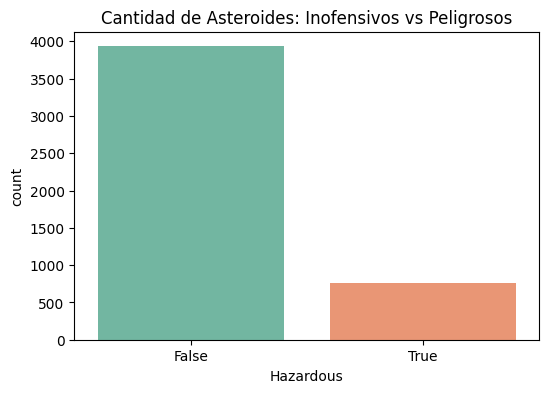

In [ ]:
# Distribución de clases)
# Vemos a qué nos enfrentamos: ¿Hay muchos asteroides peligrosos?
plt.figure(figsize=(6, 4))
sns.countplot(x='Hazardous', data=df_asteroides, palette='Set2')
plt.title("Cantidad de Asteroides: Inofensivos vs Peligrosos")
plt.show()

In [46]:
# que % corresponde a True y cuanto corresposponde a False
asteroide_T = df_asteroides[df_asteroides["Hazardous"]== True]
asteroide_F = df_asteroides[df_asteroides["Hazardous"]== False]
print(len(asteroide_T) + len(asteroide_F) == len(df_asteroides))

print(f"% de asteroides peligrosos: {round((len(asteroide_T)/ len(df_asteroides)) * 100,2)} %")
print(f"% de asteroides no peligrosos: {round((len(asteroide_F)/ len(df_asteroides)) * 100,2)} %")


True
% de asteroides peligrosos: 16.11 %
% de asteroides no peligrosos: 83.89 %


Vemos que hay un desbalance entre las clases, porque el dataset muestra que la mayoria (84%) son asteroides no peligrosos entonces al momento de predecir no tiene tanta info para decir que es un asteroide peligroso.
Este problema debe ser tratado antes de comenzar con los modelos. 

Algunas alternativas:
1. No hacer nada (baseline)
2. Ajustar los pesos de las clases (class_weight), donde el algoritmo penaliza más los errores cometidos sobre la clase minoritaria.
3. Oversampling: Consiste en aumentar artificialmente la cantidad de ejemplos de la clase minoritaria. **SMOTE** es un metodo muy utilizado que genera nuevos ejemplos sintéticos de asteroides peligrosos.
4. Undersampling: Hace lo contrario. Reduce la cantidad de ejemplos de la clase mayoritaria. Ventaja es que si efectivamente balancea el dataset, pero la principal desventaja es pierde información.
5. Combinación de ambos: un poco de undersampling + un poco de SMOTE.
6. Cambiar el umbral de decisión: por defecto los clasificadores usan probabilidad > 0.5 pero se puede bajar a 0.30. Pero ojo suele aumentar el recall, aunque puede reducir la precision.




## Justificación de la selección del modelo

El problema que enfrentamos es de **clasificación binaria**: cada asteroide debe ser catalogado como **peligroso (1)** o **inofensivo (0)** en función de las características representadas en el dataset (físicas y orbitales). No se trata de predecir un valor numérico continuo, sino de asignar una etiqueta discreta, por lo que los modelos de regresión lineal clásicos no son adecuados.

Tres modelos de clasificación:

1. **Regresión Logística**: Corresponde al modelo lineal de referencia para clasificación binaria. Produce probabilidades interpretables y permite analizar qué variables (pesos del modelo) influyen más en la decisión. Su simplicidad también la hace útil como *baseline* para comparar con modelos más complejos.

2. **K-Nearest Neighbors (KNN)**: Es un modelo no paramétrico basado en la similitud entre observaciones. Clasifica cada asteroide según la categoría predominante entre sus **k vecinos más cercanos** en el espacio de características. A diferencia de la Regresión Logística, KNN no asume una relación lineal entre las variables y la clase objetivo, por lo que puede capturar fronteras de decisión más complejas. Sin embargo, su desempeño depende fuertemente de la elección del número de vecinos y del escalado de las variables, ya que utiliza medidas de distancia para realizar la clasificación.

3. **Random Forest (Bosque Aleatorio)**: Es un ensamble de árboles de decisión que captura relaciones no lineales entre las variables, algo que la regresión logística no puede hacer. Además, es robusto frente a valores atípicos y no requiere un escalado estricto de las features. Resulta especialmente útil cuando las relaciones entre las variables predictoras y la variable objetivo no son puramente lineales, como es frecuente en datos astronómicos.

Comparar estos modelos nos permite evaluar si la complejidad adicional del Random Forest realmente mejora el rendimiento frente a la línea base de la Regresión Logística.

Resumen de modelos implementados
- Regresión Logística → modelo lineal.
- KNN → modelo basado en instancias/distancias.
- Random Forest → modelo basado en árboles y ensambles.

In [51]:
# Codificación: Transformamos la etiqueta Peligroso (True) = 1, Inofensivo (False) = 0
df_asteroides['Peligro_Numerico'] = df_asteroides['Hazardous'].astype(int)


In [52]:
# Separación de variables
X = df_asteroides[['Absolute Magnitude', 'Est Dia in KM(max)', 'Relative Velocity km per hr', 'Miss Dist.(Astronomical)']]
y = df_asteroides['Peligro_Numerico']

In [53]:
# Escalado de variables numéricas
# Fundamental para que las distancias gigantes en el espacio no aplasten a las otras variables en la fórmula
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)


In [54]:
# Dividimos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X_escalado, y, test_size=0.20, random_state=42)


In [55]:
#Funcion para evaluar los distintos modelos
def evaluar(nombre, modelo, Xtr, Xte, ytr, yte, threshold=0.5):
    modelo.fit(Xtr,ytr)
    if hasattr(modelo,"predict_proba"):
        proba=modelo.predict_proba(Xte)[:,1]
        pred=(proba>=threshold).astype(int)
        roc=roc_auc_score(yte,proba)
    else:
        pred=modelo.predict(Xte)
        roc=np.nan

    return {
        "Modelo":nombre,
        "Accuracy":accuracy_score(yte,pred),
        "Precision":precision_score(yte,pred,zero_division=0),
        "Recall":recall_score(yte,pred,zero_division=0),
        "F1":f1_score(yte,pred,zero_division=0),
        "ROC AUC":roc
    }

resultados=[]


In [57]:
#01. Este es el primer modelo base donde no se trata el tema del desbalanceo
#  de las prligrosidad o no peligrosidad del asteroide
# Tampoco se da importancia a los hiperparaemtros
resultados.append(evaluar("Logística - Baseline",
                          LogisticRegression(max_iter=1000),
                          X_train,X_test,y_train,y_test))

resultados.append(evaluar("KNN - Baseline",
                          KNeighborsClassifier(n_neighbors=5),
                          X_train,X_test,y_train,y_test))

resultados.append(evaluar("Random Forest - Baseline",
                          RandomForestClassifier(random_state=42),
                          X_train,X_test,y_train,y_test))

In [58]:
# 2. Class Weight = Balanced pero solo en la regesion logistica y  en RF, no se hace en KKN
#porque no esta esa opcion
resultados.append(evaluar("Logística - class_weight",
                          LogisticRegression(class_weight="balanced",max_iter=1000),
                          X_train,X_test,y_train,y_test))

resultados.append(evaluar("Random Forest - class_weight",
                          RandomForestClassifier(class_weight="balanced",random_state=42),
                          X_train,X_test,y_train,y_test))

In [59]:
# 3. Esta es la tecnica SMOTE, donde lo que hace es aumentar la muestra artificialmente
# Es independiente al modelo que se use
sm=SMOTE(random_state=42)
X_sm,y_sm=sm.fit_resample(X_train,y_train)

for nombre,modelo in [
    ("Logística - SMOTE",LogisticRegression(max_iter=1000)),
    ("KNN - SMOTE",KNeighborsClassifier(n_neighbors=5)),
    ("Random Forest - SMOTE",RandomForestClassifier(random_state=42))
]:
    resultados.append(evaluar(nombre,modelo,X_sm,X_test,y_sm,y_test))

In [60]:
# 4. Random UnderSampling. Esta es una metodologia menos usada (y no tan recomendad)
# lo que hace es disminuir la muestra

rus=RandomUnderSampler(random_state=42)
X_us,y_us=rus.fit_resample(X_train,y_train)

for nombre,modelo in [
    ("Logística - UnderSampling",LogisticRegression(max_iter=1000)),
    ("KNN - UnderSampling",KNeighborsClassifier(n_neighbors=5)),
    ("Random Forest - UnderSampling",RandomForestClassifier(random_state=42))
]:
    resultados.append(evaluar(nombre,modelo,X_us,X_test,y_us,y_test))

In [ ]:
## 5. SMOTE + Tomek Es una combinacion de las ultimas dos metodologias
smt=SMOTETomek(random_state=42)
X_st,y_st=smt.fit_resample(X_train,y_train)

for nombre,modelo in [
    ("Logística - SMOTE+Tomek",LogisticRegression(max_iter=1000)),
    ("KNN - SMOTE+Tomek",KNeighborsClassifier(n_neighbors=5)),
    ("Random Forest - SMOTE+Tomek",RandomForestClassifier(random_state=42))
]:
    resultados.append(evaluar(nombre,modelo,X_st,X_test,y_st,y_test))

In [61]:
## 6. Cambio del umbral. Tambien muy utilizado pero ojo! como seleccionamos un nuevo umbral eficiente 
#de acuerdo a nuestros datos
resultados.append(evaluar("Logística - Threshold 0.30",
                          LogisticRegression(max_iter=1000),
                          X_train,X_test,y_train,y_test,
                          threshold=0.30))

resultados.append(evaluar("Random Forest - Threshold 0.30",
                          RandomForestClassifier(random_state=42),
                          X_train,X_test,y_train,y_test,
                          threshold=0.30))

resultados.append(evaluar("KNN - Threshold 0.30",
                          KNeighborsClassifier(n_neighbors=5),
                          X_train,X_test,y_train,y_test,
                          threshold=0.30))

In [71]:
# Comparativa de todas las prueba
df_resultados=pd.DataFrame(resultados)
df_resultados=df_resultados.sort_values("F1",ascending=False)
dataset= pd.DataFrame(df_resultados)
dataset

,Modelo,Accuracy,Precision,Recall,F1,ROC AUC
13,Random Forest - UnderSampling,0.694030,0.326733,0.897959,0.479129,0.848384
10,Random Forest - SMOTE,0.798507,0.397059,0.551020,0.461538,0.848779
12,KNN - UnderSampling,0.679104,0.311275,0.863946,0.457658,0.821285
15,Random Forest - Threshold 0.30,0.778252,0.369099,0.585034,0.452632,0.850065
11,Logística - UnderSampling,0.668443,0.303828,0.863946,0.449558,0.789847
8,Logística - SMOTE,0.669510,0.302663,0.850340,0.446429,0.782545
5,Random Forest - Baseline,0.851812,0.538462,0.380952,0.446215,0.850065
2,Random Forest - Baseline,0.851812,0.538462,0.380952,0.446215,0.850065
6,Logística - class_weight,0.668443,0.301932,0.850340,0.445633,0.783577
9,KNN - SMOTE,0.737740,0.331058,0.659864,0.440909,0.782395


C:\Users\Josefina Urquiza\AppData\Local\Temp\ipykernel_2708\2828027932.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


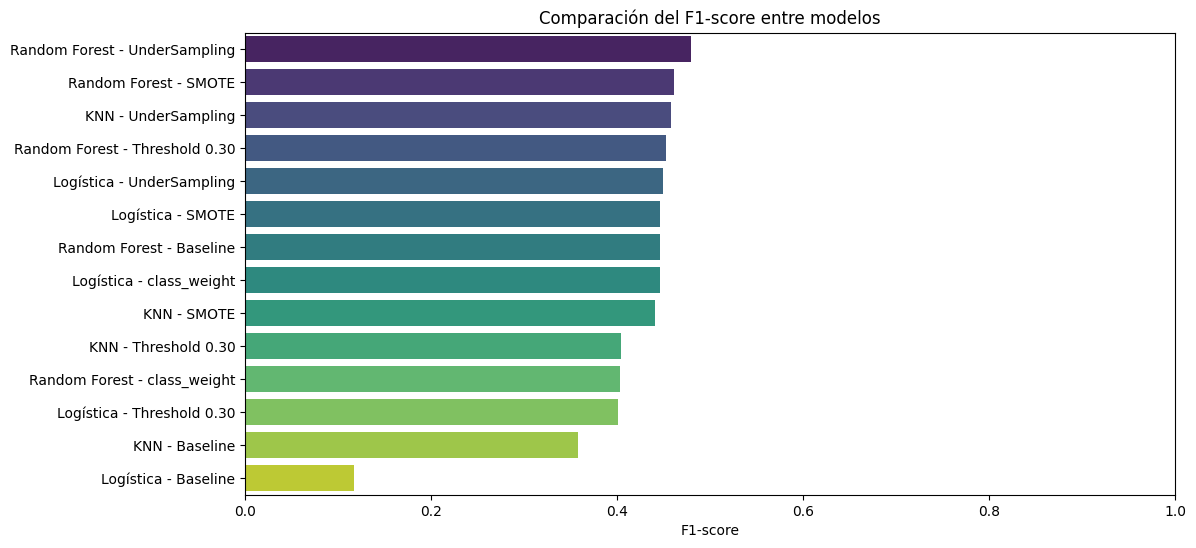

In [64]:
# Ploteamos las distintas metricas para entenderlo mejor
plt.figure(figsize=(12,6))

df_graf = df_resultados.sort_values("F1", ascending=False)

sns.barplot(
    data=df_graf,
    x="F1",
    y="Modelo",
    palette="viridis"
)

plt.title("Comparación del F1-score entre modelos")
plt.xlabel("F1-score")
plt.ylabel("")

plt.xlim(0,1)

plt.show()

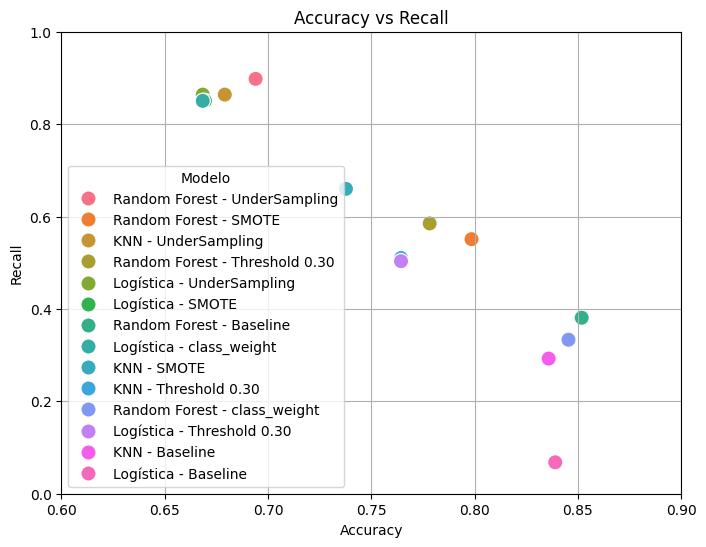

In [65]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_resultados,
    x="Accuracy",
    y="Recall",
    hue="Modelo",
    s=120
)

plt.xlim(0.6,0.9)
plt.ylim(0,1)

plt.grid(True)

plt.title("Accuracy vs Recall")

plt.show()

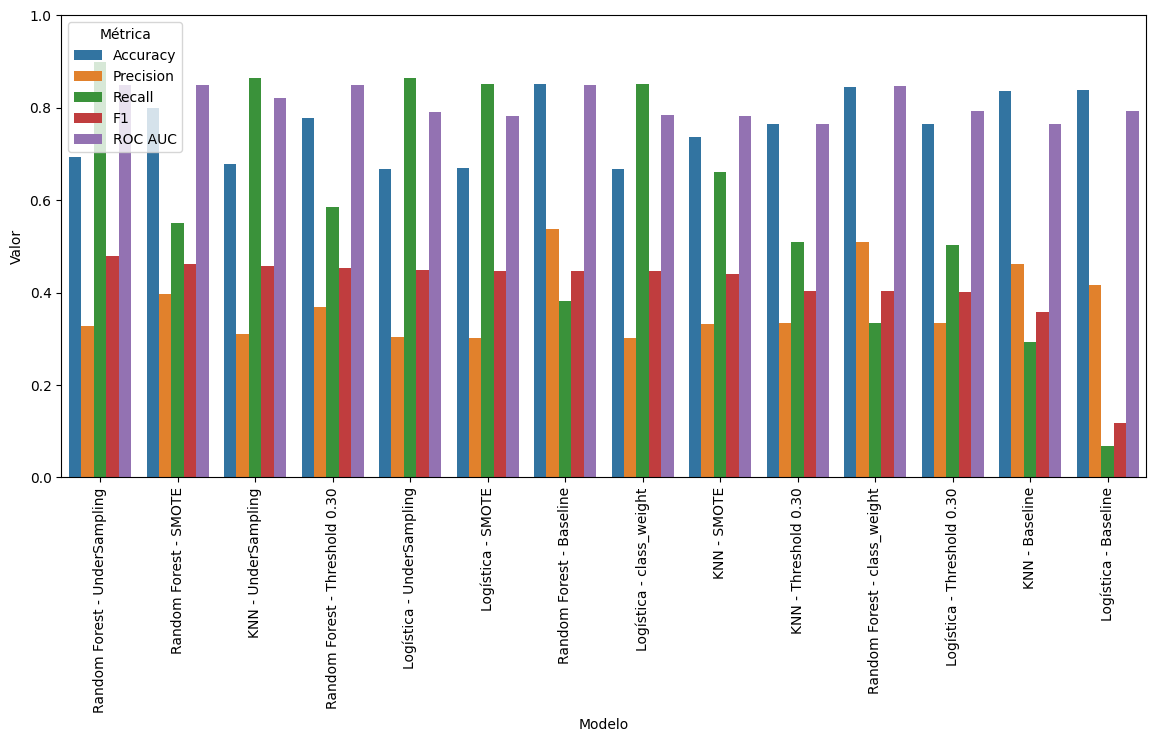

In [68]:
df_long = df_resultados.melt(
    id_vars="Modelo",
    value_vars=["Accuracy","Precision","Recall","F1","ROC AUC"],
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(14,6))

sns.barplot(
    data=df_long,
    x="Modelo",
    y="Valor",
    hue="Métrica"
)

plt.xticks(rotation=90)

plt.ylim(0,1)

plt.show()